# Set Up

## Mount Google Drive

Ignore if not using Google Collab:

In [1]:
from google.colab import drive

# mount google drive
drive.mount('/content/drive')
%cd /content/drive/My Drive
!git clone https://github.com/FranciscoLozCoding/cooling_with_code.git
%cd cooling_with_code
!git pull

Mounted at /content/drive
/content/drive/My Drive
fatal: destination path 'cooling_with_code' already exists and is not an empty directory.
/content/drive/My Drive/cooling_with_code
remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 559 bytes | 0 bytes/s, done.
From https://github.com/FranciscoLozCoding/cooling_with_code
   5efe3fe..e836750  main       -> origin/main
Updating 5efe3fe..e836750
Fast-forward
 09_adding_energy_data.ipynb | 39 ++++++++++++++++++++-------------------
 1 file changed, 20 insertions(+), 19 deletions(-)
fatal: cannot exec '.git/hooks/post-merge': Permission denied


## Import Libraries

In [2]:
%%capture
%pip install shap
%pip install stackstac
%pip install pystac-client
%pip install planetary-computer
%pip install odc-stac
%pip install rioxarray
%pip install geopy
%pip install geopandas
%pip install keras-tuner

In [3]:
# Supress Warnings
import warnings
warnings.filterwarnings('ignore')

#data science
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFECV
from sklearn.model_selection import GridSearchCV
import pickle
import shap
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Dense, Dropout, Input, Add, BatchNormalization, Activation
from tensorflow.keras.regularizers import l1_l2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import keras_tuner as kt

#other
import os

#custom tools
from tools.environment import VALID_SPLIT, RANDOM_STATE, TARGET_VARIABLE
from tools.feature_selection import (
    get_feature_importance,
    plot_feature_importance_comparison,
    perm_importance,
    plot_perm_importance_comparison,
    rfe_importance,
    plot_rfe_importance)
from tools.distribution import plot_target_var_distribution
from tools.preprocess import apply_preprocessing_mixed_buffers, load_and_preprocess_data
from tools.explainer import Explainer
from tools.build_dataset import combine_buffer_datasets

In [49]:
train_combined, test_combined = combine_buffer_datasets('data/train/v2', 'data/test/v2')

Loading training data: data/train/v2/50m_buffer_dataset.csv
Loading test data: data/test/v2/50m_buffer_test_dataset.csv
Loading training data: data/train/v2/100m_buffer_dataset.csv
Loading test data: data/test/v2/100m_buffer_test_dataset.csv
Loading training data: data/train/v2/150m_buffer_dataset.csv
Loading test data: data/test/v2/150m_buffer_test_dataset.csv
Loading training data: data/train/v2/300m_buffer_dataset.csv
Loading test data: data/test/v2/300m_buffer_test_dataset.csv

Final Training Dataset Shape: (11229, 125)
Final Test Dataset Shape: (1040, 126)


In [50]:
train_combined, test_combined = apply_preprocessing_mixed_buffers(train_combined, test_combined, energy_features=True)


Final Processed Training Dataset Shape: (11229, 284)
Final Processed Testing Dataset Shape: (1040, 285)


# Mixed Buffers RandomForestRegressor

In [51]:
# Separate features and target
y = train_combined['UHI']
X = train_combined.drop('UHI', axis=1)

# Remove constant columns
X = X.loc[:, X.std() != 0]

#scale
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

#split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=VALID_SPLIT, random_state=RANDOM_STATE
)

#make into df
x_train_df = pd.DataFrame(X_train, columns=X.columns)
x_valid_df = pd.DataFrame(X_valid, columns=X.columns)

In [ ]:
# Base Random Forest Model
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)

# Recursive Feature Elimination with Cross-Validation
rfe = RFECV(estimator=rf, step=1, cv=5, scoring="r2", n_jobs=-1)

# Fit to training data
rfe.fit(x_train_df, y_train)

# Get selected features
selected_features = x_train_df.loc[:, rfe.support_]

# Get names of selected features
selected_feature_names = x_train_df.columns[rfe.support_]

# Print selected feature names
print("Selected Features:", list(selected_feature_names))

Selected Features: ['50m_NDWI', '50m_1NPCRI', '50m_1Building_Construction_Year', '50m_1Ground_Elevation', '50m_1Fuel_Oil_2_Use_kBtu', '50m_1Fuel_Oil_4_Use_kBtu', '50m_1Electricity_Use_Grid_Purchase_kBtu', '50m_Building_Wind_Y', '50m_Elevation_Wind_Y', '50m_Traffic_NDVI', '100m_NDVI', '100m_SI', '100m_NPCRI', '100m_Coastal_Aerosol', '100m_Building_Construction_Year', '100m_Elevation_Wind_X', '100m_BldgHeight_Count', '100m_Humidity_NDVI', '100m_Water_Use_Per_Area', '100m_Fuel_Dependency', '150m_Building_Wind_X', '150m_Elevation_Wind_Y', '150m_Temp_BuildingDensity', '150m_Building_Aspect_Ratio', '150m_Permeable_Impermeable_Ratio', '150m_Water_Use_Per_Area', '150m_Fuel_Dependency', '300m_NDWI', '300m_SI', '300m_NPCRI', '300m_Coastal_Aerosol', '300m_Building_Count', '300m_Building_Construction_Year', '300m_Ground_Elevation', '300m_Weather_Normalized_Site_EUI_kBtu_ft2', '300m_Fuel_Oil_2_Use_kBtu', '300m_Fuel_Oil_4_Use_kBtu', '300m_Direct_GHG_Emissions_MetricTons_CO2e', '300m_Water_Use_All_So

In [52]:
#with energy variables
selected_feature_names=['50m_NDWI', '50m_1NPCRI', '50m_1Building_Construction_Year',
                        '50m_1Ground_Elevation', '50m_1Fuel_Oil_2_Use_kBtu', '50m_1Fuel_Oil_4_Use_kBtu',
                        '50m_1Electricity_Use_Grid_Purchase_kBtu', '50m_Building_Wind_Y', '50m_Elevation_Wind_Y',
                        '50m_Traffic_NDVI', '100m_NDVI', '100m_SI', '100m_NPCRI', '100m_Coastal_Aerosol',
                        '100m_Building_Construction_Year', '100m_Elevation_Wind_X', '100m_BldgHeight_Count',
                        '100m_Humidity_NDVI', '100m_Water_Use_Per_Area', '100m_Fuel_Dependency',
                        '150m_Building_Wind_X', '150m_Elevation_Wind_Y', '150m_Temp_BuildingDensity',
                        '150m_Building_Aspect_Ratio', '150m_Permeable_Impermeable_Ratio', '150m_Water_Use_Per_Area',
                        '150m_Fuel_Dependency', '300m_NDWI', '300m_SI', '300m_NPCRI', '300m_Coastal_Aerosol',
                        '300m_Building_Count', '300m_Building_Construction_Year', '300m_Ground_Elevation',
                        '300m_Weather_Normalized_Site_EUI_kBtu_ft2', '300m_Fuel_Oil_2_Use_kBtu', '300m_Fuel_Oil_4_Use_kBtu',
                        '300m_Direct_GHG_Emissions_MetricTons_CO2e', '300m_Water_Use_All_Sources_kgal', '300m_Building_Wind_X',
                        '300m_Building_Wind_Y', '300m_Elevation_Wind_X', '300m_Elevation_Wind_Y', '300m_BldgHeight_Count',
                        '300m_BuildingDensity_NDVI', '300m_Traffic_NDVI', '300m_Temp_BuildingDensity', '300m_Traffic_NDBI',
                        '300m_BuildingAge_Temp', '300m_Building_Aspect_Ratio', '300m_Urban_Material_Index', '300m_Permeable_Impermeable_Ratio',
                        '300m_Land_Surface_Albedo', '300m_Canopy_Cover_Ratio', '300m_Soil_Moisture_Index', '300m_Traffic_Heat_Emission',
                        '300m_GHG_Proxy', '300m_Energy_Use_Per_Building', '300m_Fuel_Dependency']

In [53]:
# select features
x_train_selected = pd.DataFrame(X_train, columns=x_train_df.columns)[selected_feature_names]
x_valid_selected = pd.DataFrame(X_valid, columns=x_train_df.columns)[selected_feature_names]

In [ ]:
# Define hyperparameter grid
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}

# Initialize model
rf_model = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)

# Grid search with selected features
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

# Fit grid search to the **selected features only**
grid_search.fit(x_train_selected, y_train)

# Best parameters
print("Best Hyperparameters:", grid_search.best_params_)
print("Best R-squared Score:", grid_search.best_score_)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Hyperparameters: {'bootstrap': False, 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best R-squared Score: 0.9646568126845232


In [54]:
# save the best params so we don't have to run again
best_hparams = {'bootstrap': False, 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

In [ ]:
# best model, skip if model was already generated
model_pkl = 'models/mixed_buffers_RandomForestRegressor/mixed_buffers_RandomForestRegressor_model.pkl'
model_pkl = 'mixed_buffers_RandomForestRegressor_model.pkl' #temporary, delete later
if not os.path.exists(model_pkl):
  best_rf_model = grid_search.best_estimator_
else:
  with open(model_pkl, 'rb') as f:
    best_rf_model = pickle.load(f)

In [55]:
best_rf_model = RandomForestRegressor(**best_hparams, random_state=RANDOM_STATE, n_jobs=-1)  # Use all CPU cores

# Train the Model
best_rf_model.fit(x_train_selected, y_train)

RandomForestRegressor(bootstrap=False, max_features='log2', n_estimators=300,
                      n_jobs=-1, random_state=123)

In [56]:
# Make predictions on the training data
insample_predictions = best_rf_model.predict(x_train_selected)

# calculate R-squared score for in-sample predictions
print(f"In-Sample Evaluation:")

insample_r2 = r2_score(y_train, insample_predictions)
print(f"  Mixed buffers zone R-squared: {insample_r2}")

In-Sample Evaluation:
  Mixed buffers zone R-squared: 1.0


In [57]:
# Make predictions on the validation data
outsample_predictions = best_rf_model.predict(x_valid_selected)

# calculate R-squared score for in-sample predictions
print(f"Out-Sample Evaluation:")

outsample_r2 = r2_score(y_valid, outsample_predictions)
print(f"  Mixed buffers zone R-squared: {outsample_r2}")

Out-Sample Evaluation:
  Mixed buffers zone R-squared: 0.9696851994826778


In [58]:
# Save the model and scaler to files
with open('mixed_buffers_RandomForestRegressor_model.pkl', 'wb') as f:
    pickle.dump(best_rf_model, f)
with open('mixed_buffers_standard_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# RF Challenge Submission

In [59]:
# Remove lat and lon, for now will be combined with predicted UHI later for submission
lon = test_combined['Longitude'].values
lat = test_combined['Latitude'].values
test_dataset = test_combined.drop(columns=['Longitude', 'Latitude'])

# Remove constant columns
test_dataset = test_dataset.loc[:, X.std() != 0]

#scale
test_dataset = pd.DataFrame(scaler.transform(test_dataset),
                      columns=test_dataset.columns,
                      index=test_dataset.index)

# select features
x_test = test_dataset[selected_feature_names].values

# Model prediction
test_predictions = best_rf_model.predict(x_test)

# combine predictions with lat and lon
submission_df = pd.DataFrame({
    'Longitude': lon,
    'Latitude': lat,
    'UHI Index': test_predictions
})
submission_df

,Longitude,Latitude,UHI Index
0,-73.971665,40.788763,0.964205
1,-73.971928,40.788875,0.964318
2,-73.967080,40.789080,0.965934
3,-73.972550,40.789082,0.963806
4,-73.969697,40.787953,0.960014
...,...,...,...
1035,-73.919388,40.813803,1.037145
1036,-73.931033,40.833178,1.039613
1037,-73.934647,40.854542,1.040093
1038,-73.917223,40.815413,1.037831


Save the submission dataframe to submit into challenge portal:

In [60]:
submission_df.to_csv("mixed_buffers_RandomForestRegressor_model_submission.csv", index=False)

Score We Received:

![submission score](https://github.com/FranciscoLozCoding/cooling_with_code/blob/main/images/mixed_buffers_RandomForestRegressor_model_score.jpeg?raw=1)

# Mixed Buffers Neural Network

In [ ]:
selected_feature_names=['50m_1NPCRI', '100m_Elevation_Wind_X', '150m_Traffic_Volume',
                        '150m_Elevation_Wind_Y', '150m_Humidity_NDVI', '150m_Traffic_NDBI',
                        '300m_SI', '300m_NPCRI', '300m_Coastal_Aerosol', '300m_Total_Building_Area_m2',
                        '300m_Building_Construction_Year', '300m_Ground_Elevation', '300m_Building_Wind_X',
                        '300m_Building_Wind_Y', '300m_Elevation_Wind_Y', '300m_BldgHeight_Count',
                        '300m_TotalBuildingArea_NDVI', '300m_Traffic_NDVI', '300m_Traffic_NDBI',
                        '300m_Building_Aspect_Ratio', '300m_Sky_View_Factor', '300m_Canopy_Cover_Ratio',
                        '300m_GHG_Proxy']

In [ ]:
# Define Feedforward Neural Network
def build_spatial_uhi_model(input_shape):
    model = Sequential([
        Dense(500, activation='relu', input_shape=(input_shape,)),
        Dropout(0.3),
        Dense(400, activation='relu'),
        Dropout(0.3),
        Dense(300, activation='relu'),
        Dropout(0.3),
        Dense(200, activation='relu'),
        Dropout(0.3),
        Dense(100, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='linear')  # Output for UHI
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='mse',
                  metrics=['mae', 'mse'])

    return model

In [61]:
# Define tuned Feedforward Neural Network with Residual Connections with energy variables RFECV selected
def build_spatial_uhi_model(input_shape):
    input_layer = Input(shape=(input_shape,))

    # First dense layer
    x = Dense(1000, activation='relu')(input_layer)
    # x = Dropout(0.1)(x)

    # First Residual Block
    x_shortcut = Dense(800, activation='relu')(x)  # Shortcut path
    x = Dense(800, activation='relu')(x)
    # x = Dropout(0.1)(x)
    x = Add()([x, x_shortcut])  # Adding residual connection

    # First Residual Block
    x_shortcut = Dense(600, activation='relu')(x)  # Shortcut path
    x = Dense(600, activation='relu')(x)
    x = Dropout(0.1)(x)
    x = Add()([x, x_shortcut])  # Adding residual connection

    # First Residual Block
    x_shortcut = Dense(500, activation='relu')(x)  # Shortcut path
    x = Dense(500, activation='relu')(x)
    x = Dropout(0.2)(x)
    x = Add()([x, x_shortcut])  # Adding residual connection

    # Second Residual Block
    x_shortcut = Dense(300, activation='relu')(x)
    x = Dense(300, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Add()([x, x_shortcut])

    # Third Residual Block
    x_shortcut = Dense(200, activation='relu')(x)
    x = Dense(200, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Add()([x, x_shortcut])

    # Fourth Residual Block
    x_shortcut = Dense(50, activation='relu')(x)
    x = Dense(50, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Add()([x, x_shortcut])

    # Output Layer
    output_layer = Dense(1, activation='linear')(x)  # Predict UHI

    # Define Model
    model = Model(inputs=input_layer, outputs=output_layer)

    # Use a Learning Rate Scheduler
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.00001,
        decay_steps=20000,
        decay_rate=0.9,
    )

    # Compile Model
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
                  loss='mse',
                  metrics=['mae', 'mse'])

    return model

In [81]:
# ORIGINAL Define tuned Feedforward Neural Network with Residual Connections
def build_spatial_uhi_model(input_shape):
    input_layer = Input(shape=(input_shape,))

    # First dense layer
    x = Dense(1000, activation='relu')(input_layer)
    x = Dropout(0.2)(x)

    # # First dense layer
    # x = Dense(600, activation='relu')(input_layer)
    # x = Dropout(0.2)(x)

    # First Residual Block
    x_shortcut = Dense(800, activation='relu')(x)  # Shortcut path
    x = Dense(800, activation='relu')(x)
    x = Dropout(0.2)(x)
    x = Add()([x, x_shortcut])  # Adding residual connection

    # First Residual Block
    x_shortcut = Dense(600, activation='relu')(x)  # Shortcut path
    x = Dense(600, activation='relu')(x)
    x = Dropout(0.2)(x)
    x = Add()([x, x_shortcut])  # Adding residual connection

    # First Residual Block
    x_shortcut = Dense(500, activation='relu')(x)  # Shortcut path
    x = Dense(500, activation='relu')(x)
    x = Dropout(0.2)(x)
    x = Add()([x, x_shortcut])  # Adding residual connection

    # Second Residual Block
    x_shortcut = Dense(300, activation='relu')(x)
    x = Dense(300, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Add()([x, x_shortcut])

    # Third Residual Block
    x_shortcut = Dense(200, activation='relu')(x)
    x = Dense(200, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Add()([x, x_shortcut])

    # Fourth Residual Block
    x_shortcut = Dense(50, activation='relu')(x)
    x = Dense(50, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Add()([x, x_shortcut])

    # Output Layer
    output_layer = Dense(1, activation='linear')(x)  # Predict UHI

    # Define Model
    model = Model(inputs=input_layer, outputs=output_layer)

    # Use a Learning Rate Scheduler
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.0005,
        decay_steps=10000,
        decay_rate=0.9
    )

    # Compile Model
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
                  loss='mse',
                  metrics=['mae', 'mse'])

    return model

In [ ]:
# Function to build model with tunable hyperparameters
def build_spatial_uhi_model_wTune(hp, input_shape):
    input_layer = Input(shape=(input_shape,))

    # First dense layer
    x = Dense(hp.Int('units_1', min_value=300, max_value=600, step=100), activation='relu')(input_layer)
    x = Dropout(hp.Float('dropout_1', 0.1, 0.5, step=0.1))(x)

    # First Residual Block (500 -> 400)
    x_shortcut = Dense(hp.Int('units_2', 300, 500, 100), activation='relu')(x)
    x = Dense(hp.Int('units_2', 300, 500, 100), activation='relu')(x)
    x = Dropout(hp.Float('dropout_2', 0.1, 0.5, step=0.1))(x)
    x = Add()([x, x_shortcut])

    # Second Residual Block (400 -> 300)
    x_shortcut = Dense(hp.Int('units_3', 200, 400, 100), activation='relu')(x)
    x = Dense(hp.Int('units_3', 200, 400, 100), activation='relu')(x)
    x = Dropout(hp.Float('dropout_3', 0.1, 0.5, step=0.1))(x)
    x = Add()([x, x_shortcut])

    # Third Residual Block (300 -> 200)
    x_shortcut = Dense(hp.Int('units_4', 100, 300, 100), activation='relu')(x)
    x = Dense(hp.Int('units_4', 100, 300, 100), activation='relu')(x)
    x = Dropout(hp.Float('dropout_4', 0.1, 0.5, step=0.1))(x)
    x = Add()([x, x_shortcut])

    # Output Layer
    output_layer = Dense(1, activation='linear')(x)  # Predict UHI

    # Define Model
    model = Model(inputs=input_layer, outputs=output_layer)

    # Compile Model with Tuned Learning Rate
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp.Float('learning_rate', 1e-5, 1e-2, sampling='log')),
                  loss='mse',
                  metrics=['mae', 'mse'])

    return model

In [87]:
# Retrain model with selected features
resnet_model = build_spatial_uhi_model(x_train_selected.shape[1])

# Callbacks: Early Stopping (Monitor Val MAE) & Model Checkpoint
early_stopping = EarlyStopping(
    monitor='val_mae',    # Monitor validation MAE
    patience=20,          # Stop if no improvement for 20 epochs
    restore_best_weights=True,  # Load the best model after stopping
    mode='min'            # Minimize validation MAE
)

history = resnet_model.fit(
    x_train_selected, y_train,
    validation_data=(x_valid_selected, y_valid),
    epochs=300,  # Adjust based on convergence
    batch_size=32,
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/300
246/246 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - loss: 0.4665 - mae: 0.4138 - mse: 0.4665 - val_loss: 0.0081 - val_mae: 0.0688 - val_mse: 0.0081
Epoch 2/300
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0188 - mae: 0.0962 - mse: 0.0188 - val_loss: 0.0043 - val_mae: 0.0345 - val_mse: 0.0043
Epoch 3/300
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0122 - mae: 0.0682 - mse: 0.0122 - val_loss: 0.0016 - val_mae: 0.0295 - val_mse: 0.0016
Epoch 4/300
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0039 - mae: 0.0425 - mse: 0.0039 - val_loss: 0.0016 - val_mae: 0.0227 - val_mse: 0.0016
Epoch 5/300
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0025 - mae: 0.0318 - mse: 0.0025 - val_loss: 0.0011 - val_mae: 0.0144 - val_mse: 0.0011
Epoch 6/300
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0022 - mae: 0.0291 - mse: 0.0022 - val_loss: 0.0014 - val_mae: 0.0309 - val_mse: 0.0014
Epoch 7/300
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0013 - mae: 0.0248 - mse: 0.0

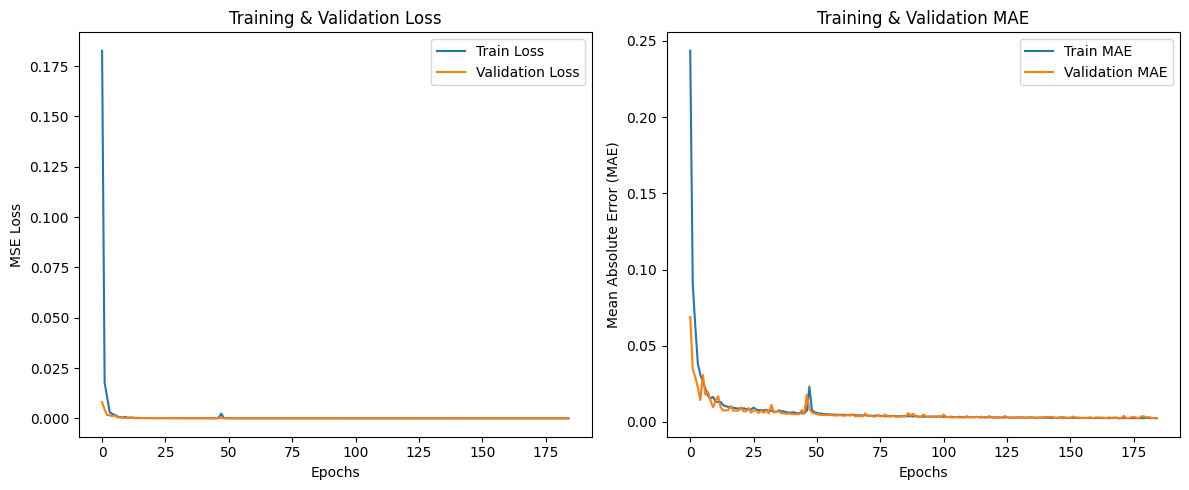

In [88]:
# Plot Learning Curves
plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Training & Validation Loss')
plt.legend()

# Plot MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('Training & Validation MAE')
plt.legend()

plt.tight_layout()
plt.show()

In [89]:
# Make predictions on the training data
insample_predictions = resnet_model.predict(x_train_selected)
ann_train_preds = insample_predictions

# calculate R-squared score for in-sample predictions
print(f"In-Sample Evaluation:")

insample_r2 = r2_score(y_train, insample_predictions)
print(f"  Mixed buffers zone R-squared: {insample_r2}")

246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
In-Sample Evaluation:
  Mixed buffers zone R-squared: 0.9716404592525715


In [90]:
# Make predictions on the validation data
outsample_predictions = resnet_model.predict(x_valid_selected)
ann_valid_preds = outsample_predictions

# calculate R-squared score for in-sample predictions
print(f"Out-Sample Evaluation:")

outsample_r2 = r2_score(y_valid, outsample_predictions)
print(f"  Mixed buffer zone R-squared: {outsample_r2}")

106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Out-Sample Evaluation:
  Mixed buffer zone R-squared: 0.9530806302425561


In [91]:
# Save the best model
resnet_model.save("mixed_buffers_ResNet_model.keras")

# Resnet Challenge Submission

We will now submit our 'ResNet' model to the challenge.
>NOTE: We can have multiple submissions.

In [9]:
# If not in runtime, load the model
resnet_model = load_model("mixed_buffers_ResNet_model.keras")

In [18]:
# Remove lat and lon, for now will be combined with predicted UHI later for submission
lon = test_combined['Longitude'].values
lat = test_combined['Latitude'].values
test_dataset = test_combined.drop(columns=['Longitude', 'Latitude'])

# Remove constant columns
test_dataset = test_dataset.loc[:, X.std() != 0]

#scale
test_dataset = pd.DataFrame(scaler.transform(test_dataset),
                      columns=test_dataset.columns,
                      index=test_dataset.index)

# select features
x_test = test_dataset[selected_feature_names].values

# Model prediction
test_predictions = resnet_model.predict(x_test)

# combine predictions with lat and lon
submission_df = pd.DataFrame({
    'Longitude': lon,
    'Latitude': lat,
    'UHI Index': test_predictions.flatten()
})
submission_df

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


,Longitude,Latitude,UHI Index
0,-73.971665,40.788763,0.962633
1,-73.971928,40.788875,0.963512
2,-73.967080,40.789080,0.962342
3,-73.972550,40.789082,0.965404
4,-73.969697,40.787953,0.959035
...,...,...,...
1035,-73.919388,40.813803,1.043934
1036,-73.931033,40.833178,1.041895
1037,-73.934647,40.854542,1.036286
1038,-73.917223,40.815413,1.040027


Save the submission dataframe to submit into challenge portal:

In [19]:
submission_df.to_csv("mixed_buffers_ResNet_model_submission.csv", index=False)

Score We Received:

![submission score](https://github.com/FranciscoLozCoding/cooling_with_code/blob/main/images/mixed_buffers_ResNet_model_score.jpeg?raw=1)

# Understanding the Results

Now we will use SHAP to understand the results. SHAP can show us feature importance, ranking, understand feature vs. prediction relationships, and can even explain individual predictions. This is what we need to understand the drivers of the Urban Heat Island phenomenon.

>TODO

# NOTES

- Using the features selected by Random forest does better than doing feature selectio using my ResNet model
- Using smaller neaurons in my first later gave me a worse score, so I had to increase it. Meaning Increasing the neuron count helped capture more detailed patterns in the data.
- ResNet helped in making my neural network better.
- Using Adaptive Learning Rate helped in making my neural network better
- The mixed buffer dataset improved my Random Forest model
- Also using the mixed buffer dataset helped improve my neural network model
- the neural network with variables from...
   - v1 mixed buffer dataset got a 0.95 in out-sample and 0.97 in in-sample (ORIGINAL model)
   - v2 mixed buffer dataset that were RFECV selected got a 0.63 in out-sample and a 0.84 in in-sample (model fine tuned for energy vars)
   - v2 mixed buffer dataaset that were manually selected (option 1)...
      - got a 0.95 in out-sample and 0.97 in in-sample (ORIGINAL model)
      - got a 0.78 in out-sample and 0.95 in in-sample (model fine tuned for energy vars)
   - v2 mixed buffer dataaset that were manually selected (option 2)...
      - got a 0.95 in out-sample and 0.96 in in-sample (ORIGINAL model)
      - got a 0.79 in out-sample and 0.96 in in-sample (model fine tuned for energy vars)
- v1 mixed buffer dataset with ORIGINAL model is the best, less overfitting